## Code for Figures in 

In [1]:
# preliminaries 

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

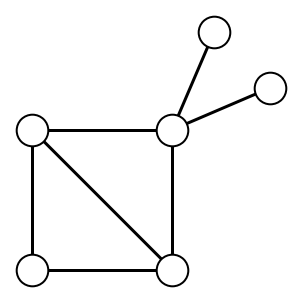

In [2]:
# graph

graph = nx.Graph()
graph.add_edges_from([(1,3),
                     (2,3),
                     (3,4),
                     (3,5),
                     (4,5),
                     (4,6),
                     (5,6)])
pos = {6:(0,0),
      5:(1,0),
      4:(0,1),
      3:(1,1),
      2:(1.7,1.3),
      1:(1.3,1.7)}
plt.figure(figsize=(4,4))
nx.draw(graph,
       node_color='white',
       edgecolors='black',
        pos = pos,
       node_size=1000,
       linewidths=2,
       width=3)

In [3]:
lapval, lapvec = np.linalg.eigh(nx.laplacian_matrix(graph).todense())

In [4]:
adjval, adjvec = np.linalg.eigh(nx.to_numpy_array(graph))

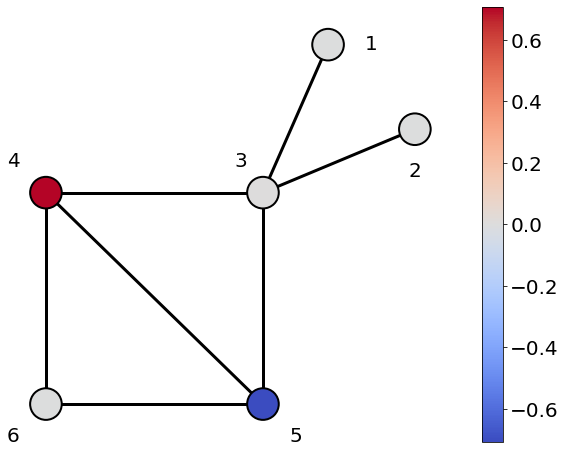

In [5]:
# adjacency matrix eigenvector 

pos2 = {6: (-.15, -.15), 
        5: (1.15, -0.15), 
        4: (-.15, 1.15), 
        3: (.9, 1.15), 
        2: (1.7, 1.1), 
        1: (1.5, 1.7)}

plt.figure(figsize=(10,8))
colors = np.array(adjvec[:, 1])

nodes = nx.draw_networkx_nodes(graph, 
                               pos, 
                               edgecolors='black',
                               node_size=1000,
                               node_color=colors, 
                                linewidths=2,
       
                               cmap='coolwarm')
edges = nx.draw_networkx_edges(graph, 
                               pos,
                              width=3) # no edges in this graph
nx.draw_networkx_labels(graph
                        , pos = pos2, font_size = 20)
bar = plt.colorbar(nodes)
bar.ax.tick_params(labelsize=20)  # Sets the font size of numbers
plt.axis('off')
plt.show()


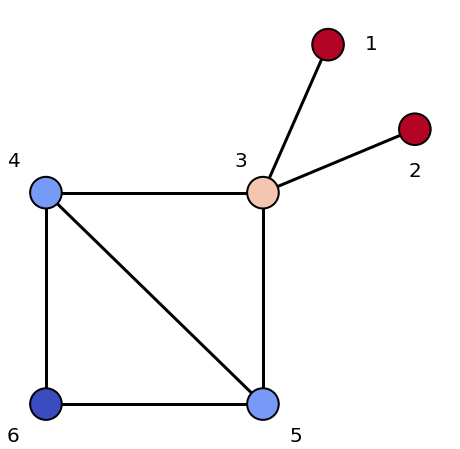

In [6]:
# laplacian matrix eigenvector 

pos2 = {6: (-.15, -.15), 
        5: (1.15, -0.15), 
        4: (-.15, 1.15), 
        3: (.9, 1.15), 
        2: (1.7, 1.1), 
        1: (1.5, 1.7)}

plt.figure(figsize=(8,8))
colors = np.array(lapvec[:, 1])
nodes = nx.draw_networkx_nodes(graph, 
                               pos, 
                               edgecolors='black',
                               node_size=1000,
                               node_color=colors, 
                                linewidths=2,
       
                               cmap='coolwarm')
edges = nx.draw_networkx_edges(graph, 
                               pos,
                              width=3) 
nx.draw_networkx_labels(graph
                        , pos = pos2, font_size = 20)
plt.axis('off')
plt.show()


In [7]:
# normalized adjacency matrix definition

normadj = np.eye(len(graph.nodes()))-nx.laplacian_matrix(graph).toarray()

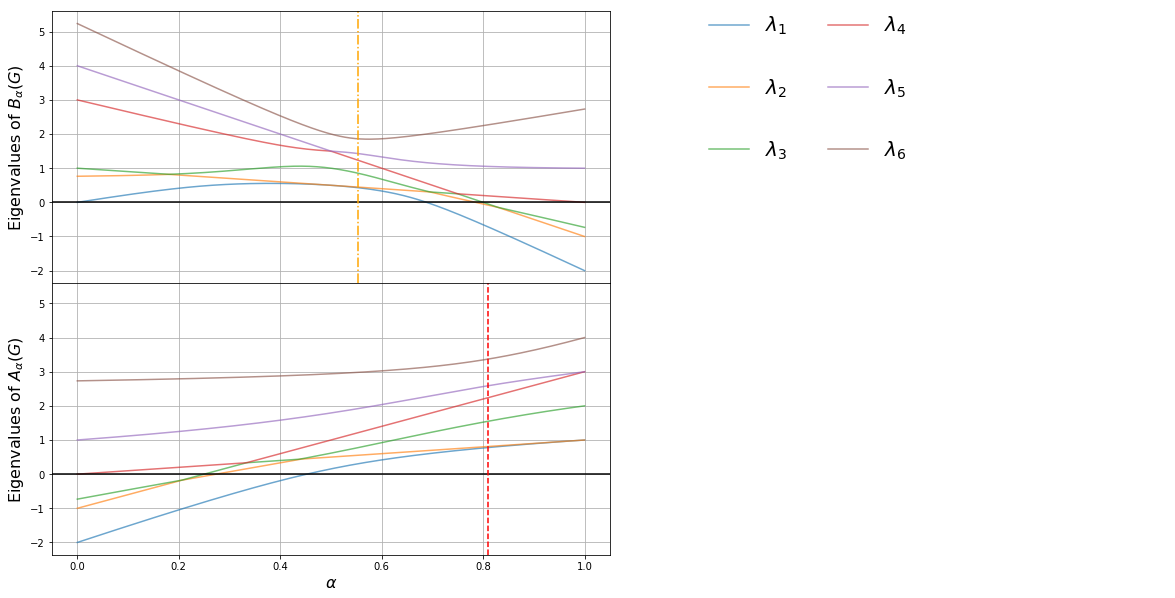

In [9]:

# B alpha matrix eigenvalue computation
eigvals = []
slices = 200
for alpha in np.linspace(0,1,slices):
    balpha = alpha*nx.to_numpy_array(graph)+(1-alpha)*nx.laplacian_matrix(graph).toarray()
    eigvals.append(np.linalg.eigh(balpha)[0])
eigvals = np.array(eigvals)


# plotting B alpha 
fig, ax = plt.subplots(2,2, sharey=True, figsize=(20,10))
fig.subplots_adjust(wspace=0, hspace=0)
for i in range(len(graph.nodes())):
    ax[0][0].plot(np.linspace(0,1,slices), eigvals[:,i], alpha=.65)
ax[0][0].set_ylabel(r'Eigenvalues of $B_{\alpha}(G)$',fontsize=16)
ax[0][0].axhline(0, color='black')
ax[0][0].grid()

# A alpha matrix eigenvalue computation
eigvals = []
degrees = [graph.degree(node) for node in graph.nodes()]
dmatrix = np.diag(degrees)
for alpha in np.linspace(0,1,slices):
    balpha = alpha*dmatrix+(1-alpha)*nx.to_numpy_array(graph)
    eigvals.append(np.linalg.eigh(balpha)[0])
    
# plotting A alpha
eigvals = np.array(eigvals)
for i in range(len(graph.nodes())):
    ax[1][0].plot(np.linspace(0,1,slices), eigvals[:,i], label=f'$\lambda_{str(i+1)}$', alpha=.65)
ax[1][0].set_xlabel(r'$\alpha$',fontsize=16)
ax[1][0].set_ylabel(r'Eigenvalues of $A_{\alpha}(G)$',fontsize=16)
ax[1][0].axhline(0, color='black')
ax[1][0].grid()
fig.legend(loc="upper center",     bbox_to_anchor=(.65, .9),     ncol=2 ,   frameon=False, fontsize=20,
          labelspacing=2)
ax[0][1].axis('off')
ax[1][1].axis('off')


# plotting transitions to PSD 
lambdan = min(np.linalg.eig(normadj)[0]) # minimum eigenvalue of norm. adj. matrix

cutoff = lambdan/(lambdan-1)
ax[1][0].axvline(cutoff, color='red', 
            label=r'$\alpha = \frac{\lambda_n(\mathcal{A})}{\lambda_n(\mathcal{A})-1}$',
           linestyle = '--')
cutoff = 1-lambdan/(2*lambdan-1)
ax[0][0].axvline(cutoff, color='orange', 
            label=r'$\alpha = \frac{\lambda_n(\mathcal{A})-1}{2\lambda_n(\mathcal{A})-1}$',
           linestyle = '-.')